# Change detection in optical satellite time series - Tutorial

<div align="center">
  
  <!-- Institution Logos -->
  <img src="https://www.umr-lastig.fr/static/lastig_1920_EN-5022e6685c1e4b6d7e84d2a08667be4e.png" height="60" alt="LASTIG">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://iadf-school.org/wp-content/uploads/2022/09/logo_iadfschool.png" height="60" alt="IADF School">
  &nbsp;&nbsp;&nbsp;&nbsp;
  <img src="https://design-system.ign.fr/img/styleguide/sg_logos/IGN_logo_RVB.png" height="60" alt="IGN">
  
  <br><br>
  
  <!-- Colab Badge -->
  [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ElliotVincent/iadf_tutorial/blob/main/tutorial_2.ipynb)
  
  
</div>

---

## **Tutorial 2: Training and Evaluating bi- and multi-temporal change detection models**

**Welcome to Tutorial 2!** In this hands-on session, you will learn how to train and evaluate bi- and multi-temporal change detection models for optical satellite image time series (SITS).

### What You'll Learn
- Train a bi- and multi-temporal semantic change detection model with optical satellite image time series
- Evaluating model performance qualitatively and quantitatively

### Prerequisites
- Basic knowledge of Python and deep learning
- Familiarity with remote sensing concepts
- Google account for Colab access
- Familiarity with the content of Tutorial 1

In [1]:
# Import necessary libraries
import copy
import matplotlib.pyplot as plt
import numpy as np
import random
import rasterio
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
!pip install -q segmentation_models_pytorch
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.base import SegmentationModel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.4 MB/s eta 0:00:00


## 1. Introduction

The following cells are mostly copied and adapted from Tutorial 1. They concern:
- image loading and visualization
- dataset definition and preparation

As a reminder, we want to solve the semantic change detection task using satellite image time series. It consists in predicting, for a given T x C x H x W tensor representing a satellite image time series:
- the 3-class T x H x W semantic maps corresponding to each time step of the input time series.
- the (T-1) x H x W binary change maps corresponding to the changes between consecutive time steps of the input time series.

In [2]:
!gdown 1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn
!gdown 1imnmKsAG83CJbddoQrKhx58ubB0XXV04
!unzip -qq "/content/data.zip"
!unzip -qq "/content/labels.zip"

Downloading...
From (original): https://drive.google.com/uc?id=1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn
From (redirected): https://drive.google.com/uc?id=1CcQKjFKLIgVqQ1df_hFMWQoHfwAKfpLn&confirm=t&uuid=e67f9d82-0266-4ede-b89f-b5056d0d7101
To: /content/data.zip
100% 171M/171M [00:01<00:00, 106MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1imnmKsAG83CJbddoQrKhx58ubB0XXV04
To: /content/labels.zip
100% 1.15M/1.15M [00:00<00:00, 114MB/s]


In [3]:
DYNAMICEARTHNET_CLASSES = {
    0: {"label": "other",                     "color": (128, 128, 128)},  # grey
    1: {"label": "vegetation",                "color": ( 34, 139,  34)},  # green
    2: {"label": "water",                     "color": ( 31, 119, 180)},  # blue
}

DATES = [f"{yyyy}-{mm:02d}-01" for yyyy in range(2018, 2020) for mm in range(1, 13)]

# Utility function to perform percentile stretching on the image for better visualization
def percentile_stretch(img, low=2, high=98):
    lo, hi = np.percentile(img, (low, high))
    img_clipped = np.clip(img, lo, hi)
    return ((img_clipped - lo) / (hi - lo) * 255).astype(np.uint8)

# Function to plot a single image
def plot_image(image):
    rgb_img = image[:3]
    rgb_img = rgb_img.transpose(1, 2, 0)
    rgb_img = percentile_stretch(rgb_img)
    plt.imshow(rgb_img)
    plt.axis('off')

# Function to plot a single label
def plot_labels(label):
    rgb_label = np.zeros((label.shape[0], label.shape[1], 3), dtype=np.uint8)
    for i in range(3):
        rgb_label[label == i] = DYNAMICEARTHNET_CLASSES[i]["color"]
    plt.imshow(rgb_label)
    plt.axis('off')

# Function to plot a time series of images and labels
def plot_time_series(images, labels, num_images=10):
    num_images = min(num_images, len(images))
    fig, axes = plt.subplots(3, num_images, figsize=(int(4*num_images / 3), 4))
    for i in range(num_images):
        # Plot the image
        rgb_img = images[i, :3].transpose(1, 2, 0)
        rgb_img = percentile_stretch(rgb_img)
        axes[0, i].set_title(DATES[i], fontsize=10)
        axes[0, i].imshow(rgb_img)
        axes[0, i].axis('off')

        # Plot the semantic maps
        rgb_label = np.zeros((labels[i].shape[0], labels[i].shape[1], 3), dtype=np.uint8)
        for j in range(3):
            rgb_label[labels[i] == j] = DYNAMICEARTHNET_CLASSES[j]["color"]
        axes[1, i].imshow(rgb_label)
        axes[1, i].axis('off')

        # Plot binary change maps
        if i > 0:
            change_map = (labels[i] != labels[i-1]).astype(np.uint8) * 255
            axes[2, i].imshow(change_map, cmap='gray')
            axes[2, i].axis('off')
        else:
            axes[2, i].axis('off')
    plt.tight_layout()
    plt.show()

def load_time_series(path):
    return np.stack([rasterio.open(f"{path}/{date}.tif").read() for date in DATES], axis=0)[:, [2, 1, 0, 3]]

def load_labels(path):
    labels = np.load(f'{path}.npy')
    labels = np.where(labels == 2, 1, labels)
    labels = np.where(labels == 3, 0, labels)
    labels = np.where(labels == 4, 0, labels)
    labels = np.where(labels == 5, 2, labels)
    labels = np.where(labels == 6, 0, labels)
    return labels

Loading images and labels...


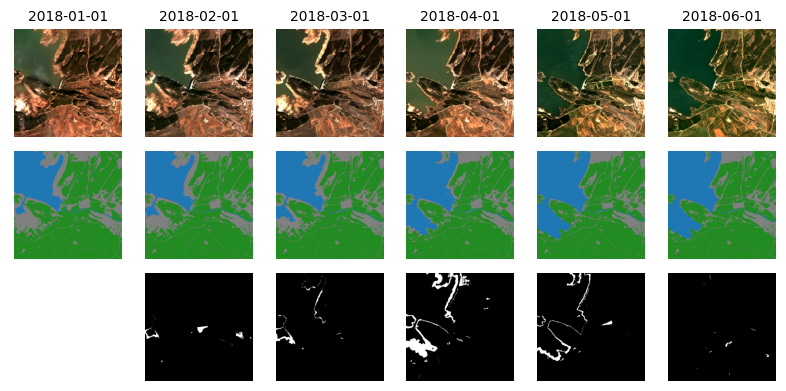

In [4]:
aoi_name = '3998_3016_13'

print(f"Loading images and labels...")
images = load_time_series(aoi_name)
labels = load_labels(aoi_name)
plot_time_series(images, labels, num_images=6)

In [5]:
class SITSDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels, split, norm=True, num_classes=3, augment=False):
        # Load the dataset once in memory
        self.data = data
        self.labels = labels
        self.norm = norm
        # Dataset statistics for normalization, from DynamicEarthNet paper
        self.mean = torch.tensor([1042.59, 915.62, 671.26, 2605.21])
        self.std = torch.tensor([957.96, 715.55, 596.94, 1059.90])
        self.num_classes = num_classes
        self.ij_lists = {"train":[[i, j] for i in range(16) for j in range(16) if j >= 8 or i < 8],
                         "val": [[i, j] for i in range(16) for j in range(16) if i >= 12 and j < 8],
                         "test": [[i, j] for i in range(16) for j in range(16) if i >= 8 and i < 12 and j < 8]}[split]
        self.split = split
        self.augment = augment

    def __len__(self):
        return len(self.ij_lists)

    def __getitem__(self, idx):
        i, j = self.ij_lists[idx]
        x, y = i*64, j*64
        if self.split == 'train' and self.augment:
          # random crop
          x = min(x + random.randint(0, 63), 7 * 64) if j < 8 else min(x + random.randint(0, 63), 15 * 64)
          y = min(y + random.randint(0, 63), 15 * 64)
        imgs = torch.tensor(self.data[..., x:x+64, y:y+64])
        labs = torch.tensor(self.labels[..., x:x+64, y:y+64])
        if self.norm:
            imgs = (imgs - self.mean[:, None, None]) / self.std[:, None, None]
        if self.augment:
            # random rotation
            rot = random.randint(0, 3)
            imgs = torch.rot90(imgs, rot, [2, 3])
            labs = torch.rot90(labs, rot, [1, 2])
            # random flip
            flip = random.randint(0, 1)
            if flip == 1:
                imgs = torch.flip(imgs, [2])
                labs = torch.flip(labs, [1])
        return imgs, labs

In [6]:
train_set = SITSDataset(data=images,
                        labels=labels,
                        split='train', norm=True, num_classes=3, augment=True)

val_set = SITSDataset(data=images,
                      labels=labels,
                      split='val', norm=True, num_classes=3)

test_set = SITSDataset(data=images,
                      labels=labels,
                      split='test', norm=True, num_classes=3)

print(f"Train dataset length: {len(train_set)}")
print(f"Validation dataset length: {len(val_set)}")
print(f"Test dataset length: {len(test_set)}")

Train dataset length: 192
Validation dataset length: 32
Test dataset length: 32


## 2. Bi-temporal baseline

The bi-temporal baseline studied here is inspired from the DualUnet described in [2]. It consists of a siamese network that processes pairs of images from consecutive time steps to predict both the semantic maps and the binary change maps.

For the U-Nets, we still use the `mobilenet_v2` backbone pretrained on `imagenet`, for a fair comparison with the post-classification approach studied in tutorial 1.

### 2.1 Model Architecture

In [7]:
def new_forward(self, x, return_features=False, sem_features=None):
    features = self.encoder(x)
    if sem_features is not None:
        sem1, sem2 = sem_features
        for (i,feat) in enumerate(features):
            if i>0:
                features[i] = feat + sem1[i] - sem2[i]
    decoder_output = self.decoder(features)
    masks = self.segmentation_head(decoder_output)
    if return_features:
        return masks, features
    else:
        return masks

SegmentationModel.forward = new_forward

class DualUnet(nn.Module):
    def __init__(self, backbone="mobilenet_v2", in_channels=4, num_classes=3):
        super(DualUnet, self).__init__()
        self.in_channels = in_channels
        self.change_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet" , in_channels=in_channels * 2, classes=2)
        self.seg_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)

    def forward(self, x):
        y1, f1 = self.seg_model(x[0], return_features=True)
        y2, f2 = self.seg_model(x[1], return_features=True)
        sem_preds = (y1, y2)
        change_pred = self.change_model(torch.cat([x[0], x[1]], dim=1), sem_features=(f1, f2))
        return change_pred, sem_preds

model = DualUnet()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 14.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Model parameters: 13,260,053


### 2.2 Training

**Note**: at each training iteration, we randomly pick 2 images out of the 24 available time steps to form a bi-temporal pair for training. Picked images are not necessarily consecutive.

In [8]:
def compute_metrics(confusion_matrix):
    # Compute overall accuracy
    overall_accuracy = torch.trace(confusion_matrix) / torch.sum(confusion_matrix)

    # Compute mean IoU
    intersection = torch.diagonal(confusion_matrix)
    union = torch.sum(confusion_matrix, dim=1) + torch.sum(confusion_matrix, dim=0) - intersection
    mean_iou = torch.mean(intersection / union)

    return overall_accuracy, mean_iou


def training_step(batch, model, criterion, optimizer, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device)
    # imgs of shape (B, T, C, H, W)
    optimizer.zero_grad()
    temp_indices = torch.tensor([random.sample(range(imgs.size(1)), 2) for _ in range(imgs.size(0))], device=imgs.device)  # (B, 2)
    batch_idx = torch.arange(imgs.size(0), device=imgs.device)[:, None]
    imgs, labs = imgs[batch_idx, temp_indices], labs[batch_idx, temp_indices]
    change_logits, sem_logits = model([imgs[:, 0], imgs[:, 1]])
    change_gt = nn.functional.one_hot((labs[:, 0] != labs[:, 1]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits, change_gt, reduction='mean')
    loss_sem = (criterion(sem_logits[0], labs[:, 0].long()) + criterion(sem_logits[1], labs[:, 1].long())) / 2
    loss = loss_change + loss_sem
    loss.backward()
    optimizer.step()
    return loss


def validation_step(batch, model, criterion, device):
    imgs, labs = batch
    imgs = imgs.to(device).squeeze(0)
    labs = labs.to(device).squeeze(0)
    # imgs of shape (1, T, C, H, W)
    imgs = torch.stack([imgs[:-1], imgs[1:]], dim=1)
    change_logits, sem_logits = model([imgs[:, 0], imgs[:, 1]])
    change_gt = nn.functional.one_hot((labs[:-1] != labs[1:]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits, change_gt, reduction='mean')
    loss_sem = (criterion(sem_logits[0], labs[:-1].long()) + criterion(sem_logits[1], labs[1:].long())) / 2
    loss = loss_change + loss_sem
    pred_change = torch.argmax(change_logits, dim=1)
    pred_sem = torch.cat([torch.argmax(sem_logits[0], dim=1)[0][None], torch.argmax(sem_logits[1], dim=1)], dim=0)
    return loss, pred_change, pred_sem, (labs[:-1] != labs[1:]).long(), labs.long()

**Note**: We use the same set of hyperparameters as in the previous tutorial for a fair comparison.

In [9]:
# Hyperparameters
batch_size = 16
learning_rate = 1e-3
num_epochs = 50

# Data loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

model = DualUnet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

device = 'cuda'
model.to(device)

logs = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": [], "val_iou_change": [], "learning_rate": []}
best_val_miou_change = 0.0
best_model_change = None
best_model_val_conf_matrix = None
best_model_val_conf_matrix_change = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    avg_train_loss = 0.0
    for batch in train_loader:
        loss = training_step(batch, model, criterion, optimizer, device)
        avg_train_loss += loss.item()
    avg_train_loss /= len(train_loader)
    print(f"   Average Training Loss: {avg_train_loss:.4f}")

    model.eval()
    avg_val_loss = 0.0
    val_conf_matrix = torch.zeros(3, 3, dtype=torch.long, device=device)
    val_conf_matrix_change = torch.zeros(2, 2, dtype=torch.long, device=device)
    with torch.no_grad():
        for batch in val_loader:
            loss, pred_change, pred_sem, labs_change, labs_sem = validation_step(batch, model, criterion, device)
            avg_val_loss += loss.item()
            val_conf_matrix += torch.bincount(pred_sem.flatten().long() * 3 + labs_sem.flatten().long(), minlength=9).reshape(3, 3)
            val_conf_matrix_change += torch.bincount(pred_change.flatten().long() * 2 + labs_change.flatten().long(), minlength=4).reshape(2, 2)
    avg_val_loss /= len(val_loader)
    acc, miou = compute_metrics(val_conf_matrix)
    change_iou = val_conf_matrix_change[1, 1] / (val_conf_matrix_change[1, 1] + val_conf_matrix_change[1, 0] + val_conf_matrix_change[0, 1])
    print(f"   Average Validation Loss: {avg_val_loss:.4f}")
    print(f"   Validation Accuracy: {acc*100:.2f}%, mIoU: {miou*100:.2f}%")
    print(f"   Change IoU: {change_iou*100:.2f}%")

    logs["train_loss"].append(avg_train_loss)
    logs["val_loss"].append(avg_val_loss)
    logs["val_acc"].append(acc.item())
    logs["val_miou"].append(miou.item())
    logs["val_iou_change"].append(change_iou.item())
    logs["learning_rate"].append(optimizer.param_groups[0]["lr"])
    if change_iou.item() > best_val_miou_change:
        best_val_miou_change = change_iou.item()
        best_model_change = copy.deepcopy(model)
        best_model_val_conf_matrix = val_conf_matrix.clone()
        best_model_val_conf_matrix_change = val_conf_matrix_change.clone()
    scheduler.step()

Epoch 1/50
   Average Training Loss: 0.9168
   Average Validation Loss: 0.5065
   Validation Accuracy: 88.13%, mIoU: 41.37%
   Change IoU: 1.35%
Epoch 2/50
   Average Training Loss: 0.5978
   Average Validation Loss: 0.3956
   Validation Accuracy: 89.13%, mIoU: 58.06%
   Change IoU: 0.91%
Epoch 3/50
   Average Training Loss: 0.5342
   Average Validation Loss: 0.3062
   Validation Accuracy: 89.56%, mIoU: 67.12%
   Change IoU: 1.47%
Epoch 4/50
   Average Training Loss: 0.4735
   Average Validation Loss: 0.3123
   Validation Accuracy: 92.65%, mIoU: 68.77%
   Change IoU: 0.06%
Epoch 5/50
   Average Training Loss: 0.4509
   Average Validation Loss: 0.2607
   Validation Accuracy: 93.42%, mIoU: 68.09%
   Change IoU: 0.00%
Epoch 6/50
   Average Training Loss: 0.4117
   Average Validation Loss: 0.2579
   Validation Accuracy: 92.06%, mIoU: 69.42%
   Change IoU: 0.87%
Epoch 7/50
   Average Training Loss: 0.4596
   Average Validation Loss: 0.2708
   Validation Accuracy: 92.11%, mIoU: 69.95%
   Cha

### 2.3 Visualization of training curves and results on validation set

When the training is complete, we can visualize the training curves and acknowledge that the model effectively learned to predict both the semantic maps and the change maps over time.

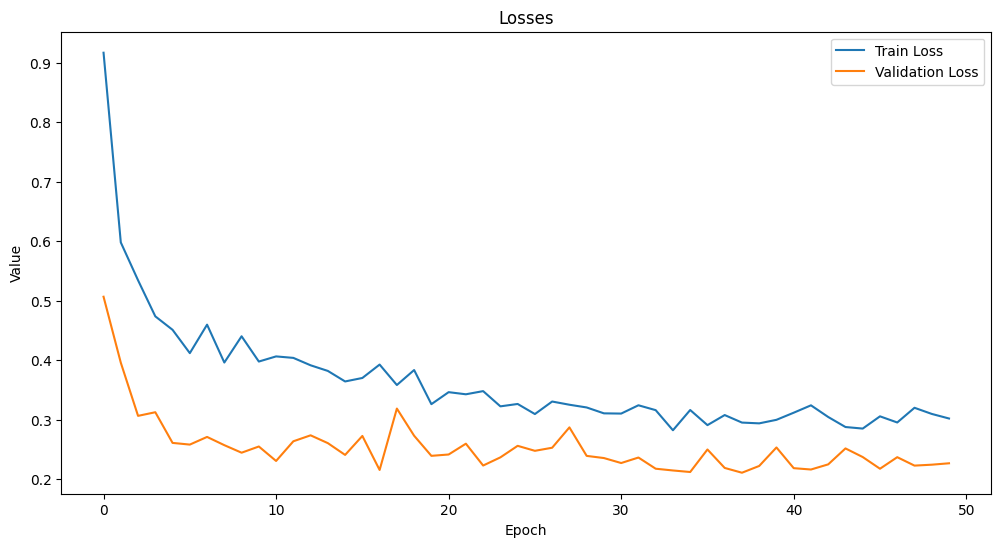

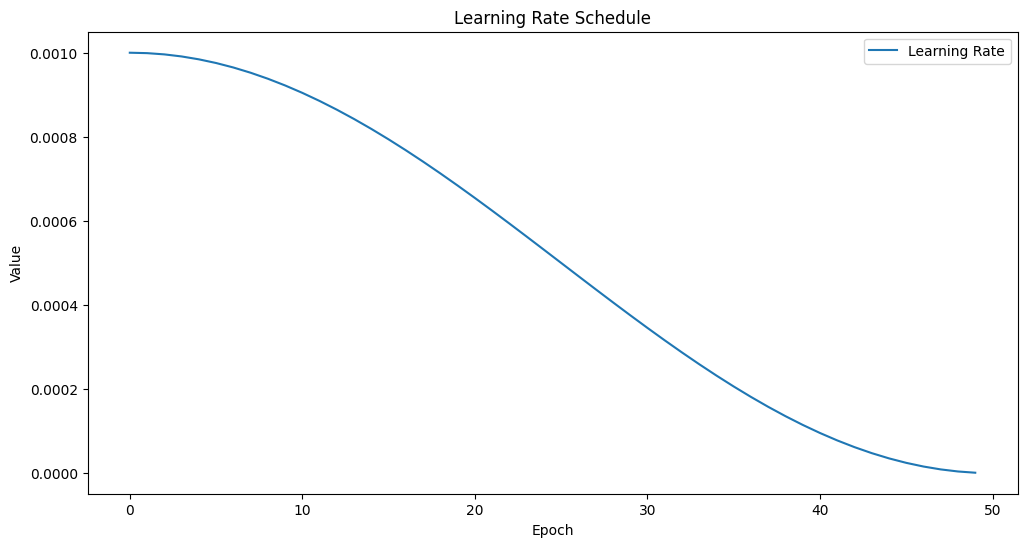

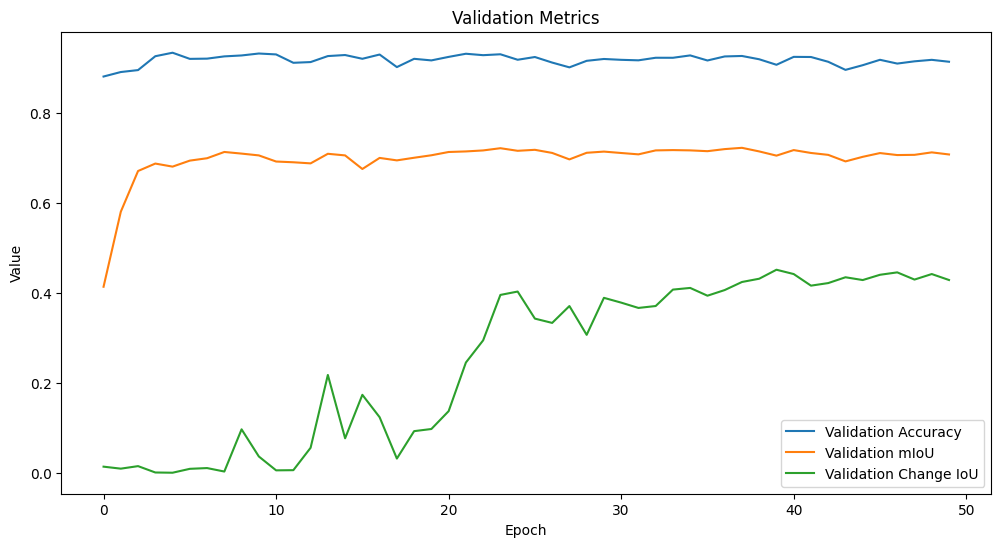

In [10]:
# Visualize the trainng curves
plt.figure(figsize=(12, 6))
plt.plot(logs["train_loss"], label="Train Loss")
plt.plot(logs["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Losses")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["learning_rate"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["val_acc"], label="Validation Accuracy")
plt.plot(logs["val_miou"], label="Validation mIoU")
plt.plot(logs["val_iou_change"], label="Validation Change IoU")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Validation Metrics")
plt.legend()
plt.show()

We can also:
- visualize the validation confusion matrix to better understand the model's performance across different classes
- print validation accuracy and mIoU
- visualize the predicted segmentation maps against their respective ground truth maps

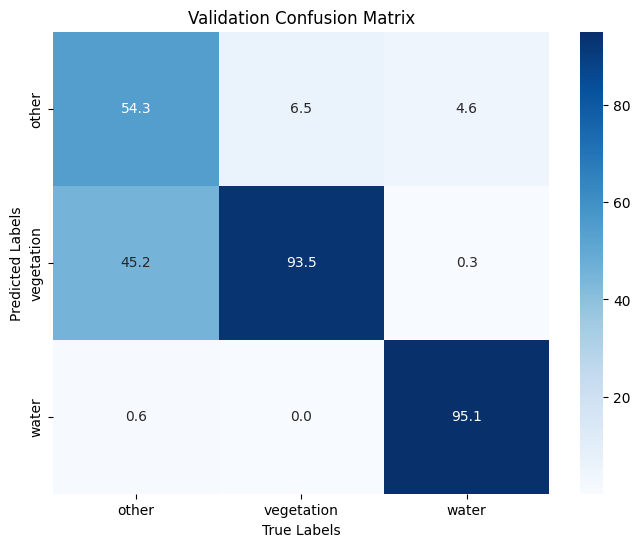

Validation Accuracy: 90.74%, mIoU: 70.53%


In [11]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix.float() / best_model_val_conf_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

val_acc = best_model_val_conf_matrix.trace().float() / best_model_val_conf_matrix.sum().float()
val_miou = (torch.diagonal(best_model_val_conf_matrix).float() / (best_model_val_conf_matrix.sum(dim=1).float() + best_model_val_conf_matrix.sum(dim=0).float() - torch.diagonal(best_model_val_conf_matrix).float())).mean()
print(f"Validation Accuracy: {val_acc*100:.2f}%, mIoU: {val_miou*100:.2f}%")

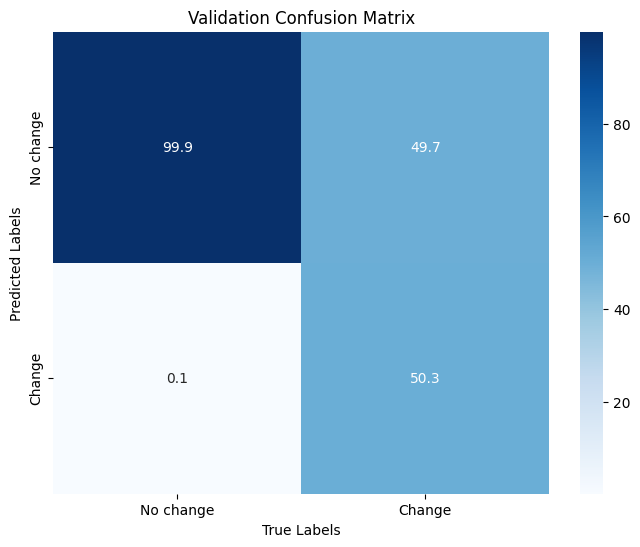

Validation Change IoU: 45.15%, FPR: 0.09%


In [12]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix_change.float() / best_model_val_conf_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=["No change", "Change"], yticklabels=["No change", "Change"])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

val_change_iou = best_model_val_conf_matrix_change[1, 1].float() / (best_model_val_conf_matrix_change[1, :].sum().float() + best_model_val_conf_matrix_change[:, 1].sum().float() - best_model_val_conf_matrix_change[1, 1].float())
val_false_positive_rate = best_model_val_conf_matrix_change[1, 0].float() / (best_model_val_conf_matrix_change[1, 0].float() + best_model_val_conf_matrix_change[0, 0].float())
print(f"Validation Change IoU: {val_change_iou*100:.2f}%, FPR: {val_false_positive_rate*100:.2f}%")

### 2.4 Evaluation on test Set

Now, let's evaluate our model on the change detection task on the test set.  
The DualUnet is infered on consecutive frames to detect changes between them.

In [13]:
canva_lab = torch.zeros(24, 256, 512).long()
canva_pred = torch.zeros(24, 256, 512).long()
canva_lab_change = torch.zeros(23, 256, 512).long()
canva_pred_change = torch.zeros(23, 256, 512).long()
ij_list = [[i, j] for i in range(4) for j in range(8)]
best_model_change.eval()
times = []
for k in range(len(test_set)):
    imgs, labs = test_set[k]
    imgs = torch.stack([imgs[:-1], imgs[1:]], dim=1).to(device)
    with torch.no_grad():
        start = time.time()
        change_logits, sem_logits = best_model_change([imgs[:, 0], imgs[:, 1]])
        end = time.time()
        times.append(end-start)
    pred_change = torch.argmax(change_logits, dim=1).detach().cpu()
    pred_sem = torch.cat([torch.argmax(sem_logits[0], dim=1)[0][None], torch.argmax(sem_logits[1], dim=1)], dim=0).detach().cpu()
    labs = labs.detach().cpu()
    labs_change = (labs[:-1] != labs[1:]).long()
    i, j = ij_list[k]
    canva_lab[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs
    canva_pred[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_sem
    canva_lab_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs_change
    canva_pred_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_change

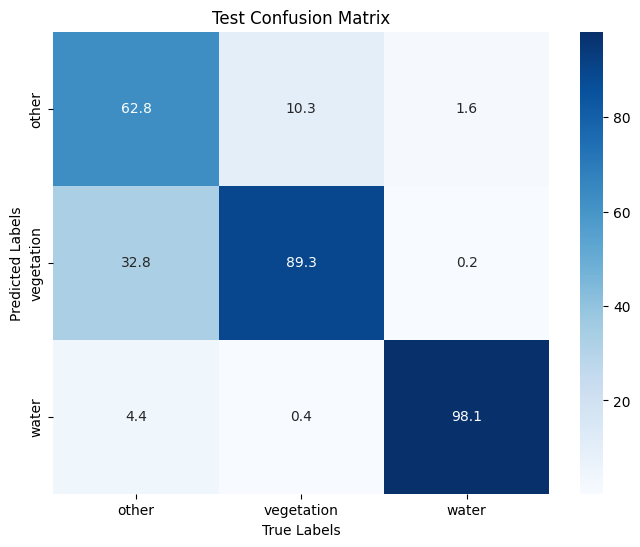

In [14]:
test_confusion_matrix = torch.bincount(canva_pred.flatten().long() * 3 + canva_lab.flatten().long(), minlength=9).reshape(3, 3)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_normalized = test_confusion_matrix.float() / test_confusion_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix')
plt.show()

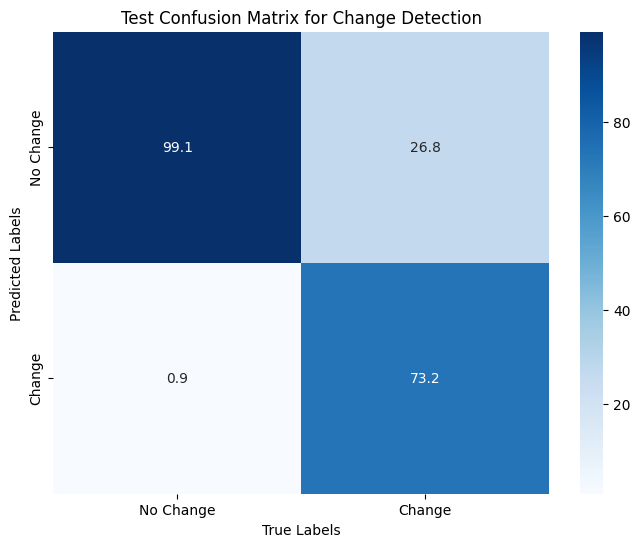

In [15]:
test_confusion_matrix_change = torch.bincount(canva_pred_change.flatten().long() * 2 + canva_lab_change.flatten().long(), minlength=4).reshape(2, 2)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_change_normalized = test_confusion_matrix_change.float() / test_confusion_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_change_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=['No Change', 'Change'], yticklabels=['No Change', 'Change'])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix for Change Detection')
plt.show()

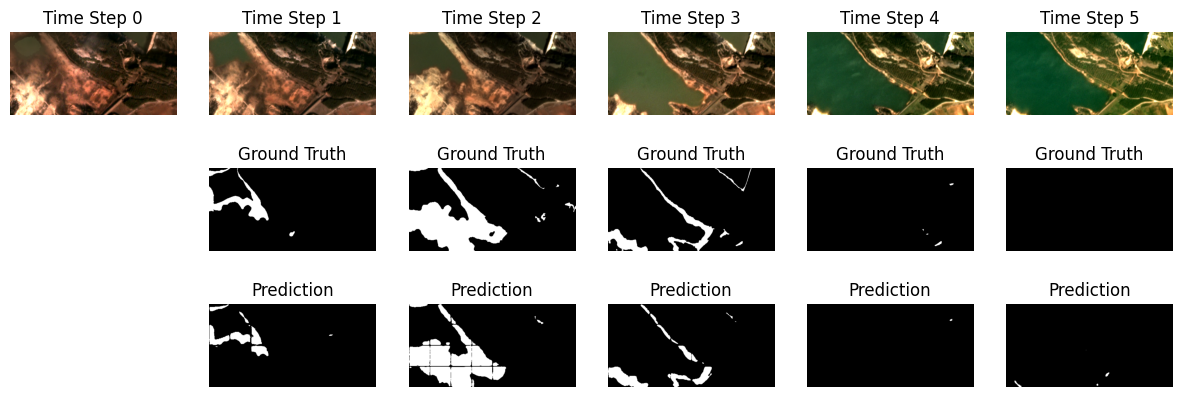

In [16]:
plt.figure(figsize=(15, 5))
for time_step in range(6):
    plt.subplot(3, 6, time_step + 1)
    plt.title(f"Time Step {time_step}")
    plot_image(images[time_step, :, 512:768:, :512])
    if time_step > 0:
        plt.subplot(3, 6, time_step + 7)
        plt.title(f"Ground Truth")
        plt.imshow(canva_lab_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
        plt.subplot(3, 6, time_step + 13)
        plt.title(f"Prediction")
        plt.imshow(canva_pred_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
plt.show()

In [17]:
def compute_SC(canva_pred, canva_lab):
    canva_lab_change = (canva_lab[1:] != canva_lab[:-1]).flatten()
    curr_canva_pred = canva_pred[1:].flatten()[canva_lab_change]
    curr_canva_lab = canva_lab[1:].flatten()[canva_lab_change]
    curr_conf_mat = torch.bincount(curr_canva_pred.long() * 3 + curr_canva_lab.long(), minlength=9).reshape(3, 3)
    per_class_iou = curr_conf_mat.diag() / (curr_conf_mat.sum(dim=1) + curr_conf_mat.sum(dim=0) - curr_conf_mat.diag())
    sc = per_class_iou.mean().item()
    return sc

acc = test_confusion_matrix.diag().sum().item() / test_confusion_matrix.sum().item()
per_class_iou = test_confusion_matrix.diag() / (test_confusion_matrix.sum(dim=1) + test_confusion_matrix.sum(dim=0) - test_confusion_matrix.diag())
miou = per_class_iou.mean().item()
change_iou = test_confusion_matrix_change[1, 1].float() / (test_confusion_matrix_change[1, 1].float() + test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 1].float())
sc = compute_SC(canva_pred, canva_lab)
false_positive_rate = test_confusion_matrix_change[1, 0].float() / (test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 0].float())

print(f"Test inference time: {np.mean(times)*1e3:.1f}ms ({np.std(times)*1e3:.1f}ms) per time series")
print(f"Sem Seg Acc:         {acc*100:.1f}")
print(f"Sem Seg mIoU:        {miou*100:.1f}")
print(f"Change IoU:          {change_iou.item() * 100:.1f}")
print(f"SC:                  {sc * 100:.1f}")
print(f"False Positive Rate: {false_positive_rate.item() * 100:.2f}")

Test inference time: 20.7ms (1.4ms) per time series
Sem Seg Acc:         86.5
Sem Seg mIoU:        74.2
Change IoU:          59.4
SC:                  61.9
False Positive Rate: 0.87


Looking at the predicted binary change mask, it seems that the DualUnet can already predict changed with much less false positive that the post-classification approach.  
This is confirmed quantitatively with a lower false positive rate. You can report the scores [in this spreadsheet](https://docs.google.com/spreadsheets/d/1ZeGHwPC2sFupiJ-KKqNgPOo-qnsbcJAFWBlYSVpHIf8/edit?usp=sharing).
Now, let's see if training a multi-temporal change detection model can further improve the performance.

## 3. Multi-Temporal Baseline

The idea here is to design a model that processes the whole time series at once, rather than comparing pairs of images independently. This allows the model to capture temporal dependencies and potentially improve change detection performance.
To do so, we build on the DualUnet architecture, with the following main modifications:
- Temporal attention: the feature maps output by the semantic encoder are processed by a temporal attention module to capture dependencies across different time steps.
- Positional encoding: to help the model distinguish between different time steps, we add positional encodings to the feature maps before feeding them into the temporal attention module. Positional encodings correspond to the number of days since the first image in the time series.

For literature on temporal attention for SITS, we refer the reader to UTAE paper [3].

### 3.1 Model Architecture

In [18]:
class ScaledDotProductAttention(nn.Module):
    """Scaled Dot-Product Attention
    Modified from github.com/jadore801120/attention-is-all-you-need-pytorch
    """
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=2)

    def forward(self, q, k, v):
        attn = torch.matmul(k, q)
        attn = attn / self.temperature
        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)
        return output, attn


class MultiDualUnet(nn.Module):
    def __init__(self, backbone="mobilenet_v2", in_channels=4, num_classes=3):
        super(MultiDualUnet, self).__init__()
        self.change_model = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels * 2, classes=2)
        self.seg_model   = smp.Unet(encoder_name=backbone, encoder_weights="imagenet", in_channels=in_channels, classes=num_classes)

        self.n_head = 4
        self.d_k    = 8
        self.d_in   = 1280

        self.fc1_q = nn.Linear(self.d_in, self.n_head * self.d_k)
        nn.init.normal_(self.fc1_q.weight, mean=0, std=np.sqrt(2.0 / self.d_k))

        self.fc1_k = nn.Linear(self.d_in, self.n_head * self.d_k)
        nn.init.normal_(self.fc1_k.weight, mean=0, std=np.sqrt(2.0 / self.d_k))

        self.attention = ScaledDotProductAttention(temperature=np.power(self.d_k, 0.5))

        self.pos_enc_proj = nn.Sequential(
            nn.Linear(self.d_in, self.d_in),  # input: sinusoidal features
            nn.GELU(),
            nn.Linear(self.d_in, self.d_in),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 64, 64)
            n_levels = len(self.seg_model.encoder(dummy))

        self.temporal_gates = nn.ParameterDict({
            str(i): nn.Parameter(torch.full((1,), -1.0))
            for i in range(1, n_levels)
        })

    def _get_gate(self, level_idx):
        return torch.sigmoid(self.temporal_gates[str(level_idx)])

    def days_to_sinusoidal(self, days, d_model):
        """
        days: B x T  (absolute day indices, float or long)
        Returns: B x T x d_model sinusoidal encoding.
        """
        d_half = d_model // 2
        freqs = torch.exp(
            torch.linspace(
                np.log(1.0 / 730),
                np.log(1.0),
                d_half,
                device=days.device
            )
        )
        angles = days.float().unsqueeze(-1) * freqs
        enc = torch.cat([torch.sin(angles), torch.cos(angles)], dim=-1)
        return enc  # B x T x d_model

    def forward(self, x, days):
        """
        x:    B x T x C x H x W
        days: B x T  — absolute day index of each acquisition
        """
        B, T, C, H, W = x.shape

        features = self.seg_model.encoder(x.reshape(-1, C, H, W))
        features = [f.reshape(B, T, *f.shape[1:]) for f in features]

        out_features, att = self.multihead_temporal_attention_model(features[-1], days)

        attended_features = [self._get_gate(len(features) - 1) * out_features + (1.0 - self._get_gate(len(features) - 1) * features[-1])]
        for i in range(len(features) - 2, 0, -1):
            agg  = self.temporal_attention_aggregation(features[i], att)
            gate = self._get_gate(i)
            blended = gate * agg + (1.0 - gate) * features[i]
            attended_features = [blended] + attended_features
        attended_features = [features[0]] + attended_features

        out_features_reshaped = [f.reshape(B * T, -1, f.shape[-2], f.shape[-1]) for f in attended_features]
        seg_logits = self.seg_model.decoder(out_features_reshaped)
        seg_logits = self.seg_model.segmentation_head(seg_logits)
        seg_logits = seg_logits.view(B, T, *seg_logits.shape[1:])

        change_features = self.change_model.encoder(
            torch.cat([x[:, :-1].reshape(-1, C, H, W),
                       x[:, 1: ].reshape(-1, C, H, W)], dim=1)
        )
        change_features = [f.reshape(B, (T - 1), -1, f.shape[-2], f.shape[-1]) for f in change_features]

        for i, feat in enumerate(change_features):
            if i > 0:
                change_features[i] = feat + features[i][:, :-1] - features[i][:, 1:]

        change_features_reshaped = [f.reshape(B * (T - 1), -1, f.shape[-2], f.shape[-1]) for f in change_features]
        change_logits = self.change_model.decoder(change_features_reshaped)
        change_logits = self.change_model.segmentation_head(change_logits)
        change_logits = change_logits.view(B, T - 1, *change_logits.shape[1:])
        return seg_logits, change_logits

    def multihead_temporal_attention_model(self, x, days):
        """
        x:    B x T x D x H x W
        days: B x T  e.g. [[24, 85, 100, ...], ...]
        """
        sz_b, seq_len, d, h, w = x.shape
        v = x.permute(0, 3, 4, 1, 2).contiguous().view(sz_b * h * w, seq_len, d)
        pos = self.days_to_sinusoidal(days, self.d_in)
        pos = self.pos_enc_proj(pos)
        pos = pos.unsqueeze(1).unsqueeze(1).expand(-1, h, w, -1, -1)
        pos = pos.contiguous().view(sz_b * h * w, seq_len, d)
        v_pos = v + pos
        q = self.fc1_q(v_pos).view(sz_b * h * w, seq_len, self.n_head, self.d_k)
        q = q.permute(2, 0, 1, 3).contiguous().view(-1, seq_len, self.d_k).permute(0, 2, 1)
        k = self.fc1_k(v_pos).view(sz_b * h * w, seq_len, self.n_head, self.d_k)
        k = k.permute(2, 0, 1, 3).contiguous().view(-1, seq_len, self.d_k)
        v = torch.stack(v.split(v.shape[-1] // self.n_head, dim=-1)).view(
            self.n_head * sz_b * h * w, seq_len, -1
        )
        output, attn = self.attention(q, k, v)
        attn   = attn.view(self.n_head, sz_b * h * w, seq_len, seq_len)
        output = output.view(self.n_head, sz_b * h * w, seq_len, self.d_in // self.n_head)
        out = output.permute(1, 2, 0, 3).contiguous().view(sz_b * h * w, seq_len, -1)
        out = out.view(sz_b, h, w, seq_len, -1).permute(0, 3, 4, 1, 2)
        attn = attn.view(self.n_head, sz_b, h, w, seq_len, seq_len).permute(0, 1, 4, 5, 2, 3)
        return out, attn

    def temporal_attention_aggregation(self, x, attn_mask):
        n_heads, b, t, _, h, w = attn_mask.shape
        attn = attn_mask.contiguous().view(n_heads * b * t, t, h, w)
        if x.shape[-2] > w:
            attn = nn.Upsample(size=x.shape[-2:], mode="bilinear", align_corners=False)(attn)
        else:
            attn = nn.AvgPool2d(kernel_size=w // x.shape[-2])(attn)
        attn = attn.view(n_heads, b, t, t, *x.shape[-2:])
        out = torch.stack(x.chunk(n_heads, dim=2))
        out = torch.einsum('nbqkhw, nbkchw -> nbqchw', attn, out)
        out = torch.cat([group for group in out], dim=2)
        return out

model = MultiDualUnet()
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 16,621,402


### 3.2 Training

**Note**: training steps are not performed with all 24 epochs but with a random subset of 6 frames in order to reduce computation time and memory usage, and add randomness to the training process.

In [19]:
DAYS = torch.tensor([0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365, 396, 424, 455, 485, 516, 546, 577, 608, 638, 669, 699], device=device)

def training_step(batch, model, criterion, optimizer, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device)
    # imgs of shape (B, T, C, H, W)
    optimizer.zero_grad()
    temp_indices = torch.tensor([random.sample(range(imgs.size(1)), 6) for _ in range(imgs.size(0))], device=imgs.device)  # (B, 2)
    temp_indices, _ = torch.sort(temp_indices, dim=1)
    batch_idx = torch.arange(imgs.size(0), device=imgs.device)[:, None]
    imgs, labs, days = imgs[batch_idx, temp_indices], labs[batch_idx, temp_indices], DAYS[None].expand((imgs.size(0), -1))[batch_idx, temp_indices]
    sem_logits, change_logits = model(imgs, days)
    change_gt = nn.functional.one_hot((labs[:, :-1] != labs[:, 1:]).long(), num_classes=2).permute(0, 1, 4, 2, 3).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits.reshape(-1, 2, 64, 64), change_gt.reshape(-1, 2, 64, 64), reduction='mean')
    loss_sem = criterion(sem_logits.reshape(-1, 3, 64, 64), labs.long().reshape(-1, 64, 64))
    loss = loss_change + loss_sem
    loss.backward()
    optimizer.step()
    return loss


def validation_step(batch, model, criterion, device):
    imgs, labs = batch
    imgs = imgs.to(device)
    labs = labs.to(device).squeeze(0)
    # imgs of shape (1, T, C, H, W)
    sem_logits, change_logits = model(imgs, DAYS.unsqueeze(0))
    change_gt = nn.functional.one_hot((labs[:-1] != labs[1:]).long(), num_classes=2).permute(0, 3, 1, 2).float()
    loss_change = torchvision.ops.sigmoid_focal_loss(change_logits.reshape(-1, 2, 64, 64), change_gt.reshape(-1, 2, 64, 64), reduction='mean')
    loss_sem = criterion(sem_logits.reshape(-1, 3, 64, 64), labs.long().reshape(-1, 64, 64))
    loss = loss_change + loss_sem
    pred_sem = torch.argmax(sem_logits.squeeze(0), dim=1)
    pred_change = torch.argmax(change_logits.squeeze(0), dim=1)
    return loss, pred_change, pred_sem, (labs[:-1] != labs[1:]).long(), labs.long()

In [20]:
# Hyperparameters
batch_size = 16
learning_rate = 1e-3
num_epochs = 50

# Data loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=1, shuffle=False)

model = MultiDualUnet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

device = 'cuda'
model.to(device)

logs = {"train_loss": [], "val_loss": [], "val_acc": [], "val_miou": [], "val_iou_change": [], "learning_rate": []}
best_val_iou_change = 0.0
best_model_change = None
best_model_val_conf_matrix = None
best_model_val_conf_matrix_change = None

for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    avg_train_loss = 0.0
    for batch in train_loader:
        loss = training_step(batch, model, criterion, optimizer, device)
        avg_train_loss += loss.item()
    avg_train_loss /= len(train_loader)
    print(f"   Average Training Loss: {avg_train_loss:.4f}")

    model.eval()
    avg_val_loss = 0.0
    val_conf_matrix = torch.zeros(3, 3, dtype=torch.long, device=device)
    val_conf_matrix_change = torch.zeros(2, 2, dtype=torch.long, device=device)
    with torch.no_grad():
        for batch in val_loader:
            loss, pred_change, pred_sem, labs_change, labs_sem = validation_step(batch, model, criterion, device)
            avg_val_loss += loss.item()
            val_conf_matrix += torch.bincount(pred_sem.flatten().long() * 3 + labs_sem.flatten().long(), minlength=9).reshape(3, 3)
            val_conf_matrix_change += torch.bincount(pred_change.flatten().long() * 2 + labs_change.flatten().long(), minlength=4).reshape(2, 2)
    avg_val_loss /= len(val_loader)
    acc, miou = compute_metrics(val_conf_matrix)
    iou_change = val_conf_matrix_change[1, 1] / (val_conf_matrix_change[1, 1] + val_conf_matrix_change[1, 0] + val_conf_matrix_change[0, 1])
    print(f"   Average Validation Loss: {avg_val_loss:.4f}")
    print(f"   Validation Accuracy: {acc*100:.2f}%, mIoU: {miou*100:.2f}%")
    print(f"   Change IoU: {iou_change*100:.2f}%")

    logs["train_loss"].append(avg_train_loss)
    logs["val_loss"].append(avg_val_loss)
    logs["val_acc"].append(acc.item())
    logs["val_miou"].append(miou.item())
    logs["val_iou_change"].append(iou_change.item())
    logs["learning_rate"].append(optimizer.param_groups[0]["lr"])
    if iou_change.item() > best_val_iou_change:
        best_val_iou_change = iou_change.item()
        best_model_change = copy.deepcopy(model)
        best_model_val_conf_matrix = val_conf_matrix.clone()
        best_model_val_conf_matrix_change = val_conf_matrix_change.clone()
    scheduler.step()

Epoch 1/50
   Average Training Loss: 0.8703
   Average Validation Loss: 0.9931
   Validation Accuracy: 52.19%, mIoU: 25.56%
   Change IoU: 0.36%
Epoch 2/50
   Average Training Loss: 0.5421
   Average Validation Loss: 0.2794
   Validation Accuracy: 93.20%, mIoU: 64.84%
   Change IoU: 0.03%
Epoch 3/50
   Average Training Loss: 0.4593
   Average Validation Loss: 0.3038
   Validation Accuracy: 91.59%, mIoU: 64.44%
   Change IoU: 0.00%
Epoch 4/50
   Average Training Loss: 0.4236
   Average Validation Loss: 0.2903
   Validation Accuracy: 91.33%, mIoU: 66.99%
   Change IoU: 0.00%
Epoch 5/50
   Average Training Loss: 0.4244
   Average Validation Loss: 0.2584
   Validation Accuracy: 92.93%, mIoU: 63.65%
   Change IoU: 0.04%
Epoch 6/50
   Average Training Loss: 0.3995
   Average Validation Loss: 0.2742
   Validation Accuracy: 92.67%, mIoU: 70.26%
   Change IoU: 0.01%
Epoch 7/50
   Average Training Loss: 0.4127
   Average Validation Loss: 0.2839
   Validation Accuracy: 90.81%, mIoU: 68.64%
   Cha

### 3.3 Visualization of training curves and results on validation set

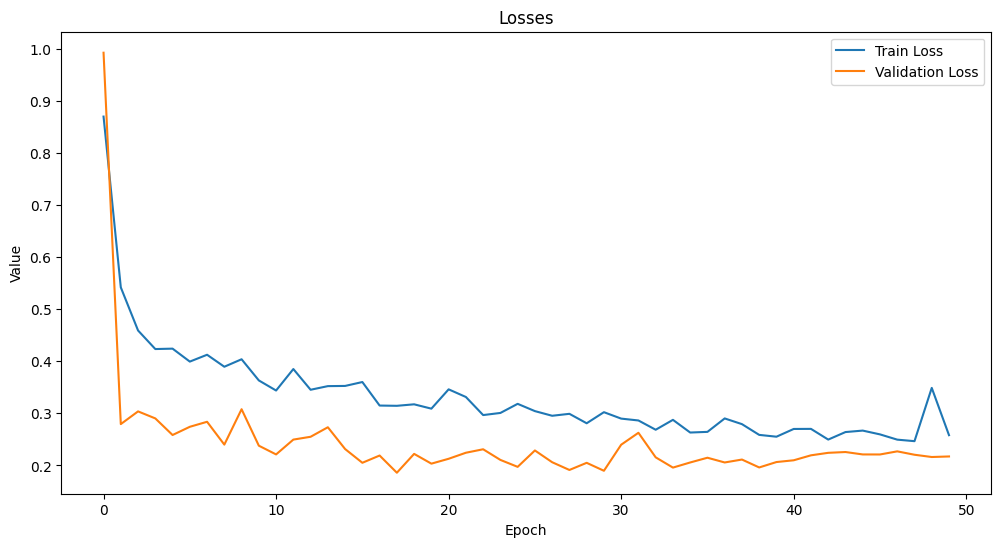

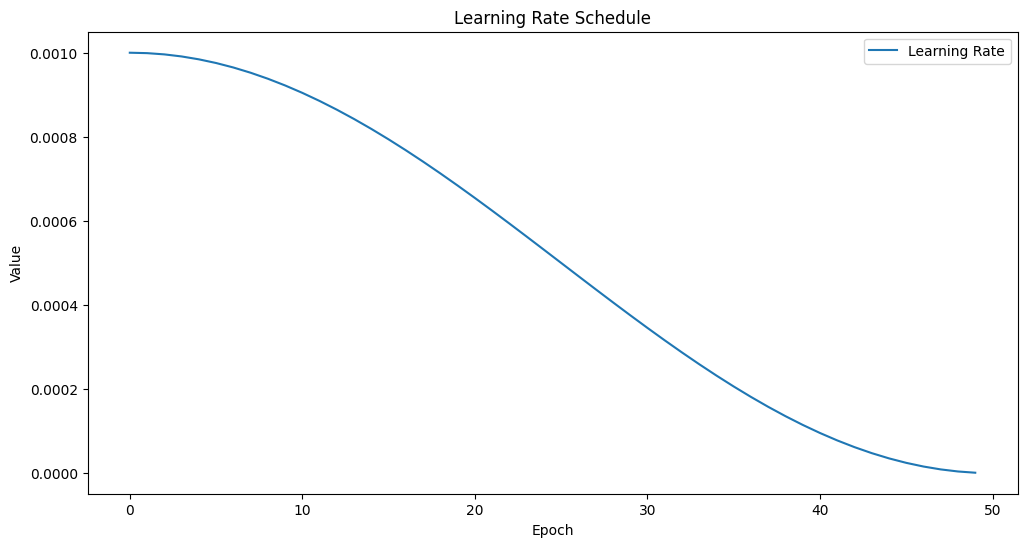

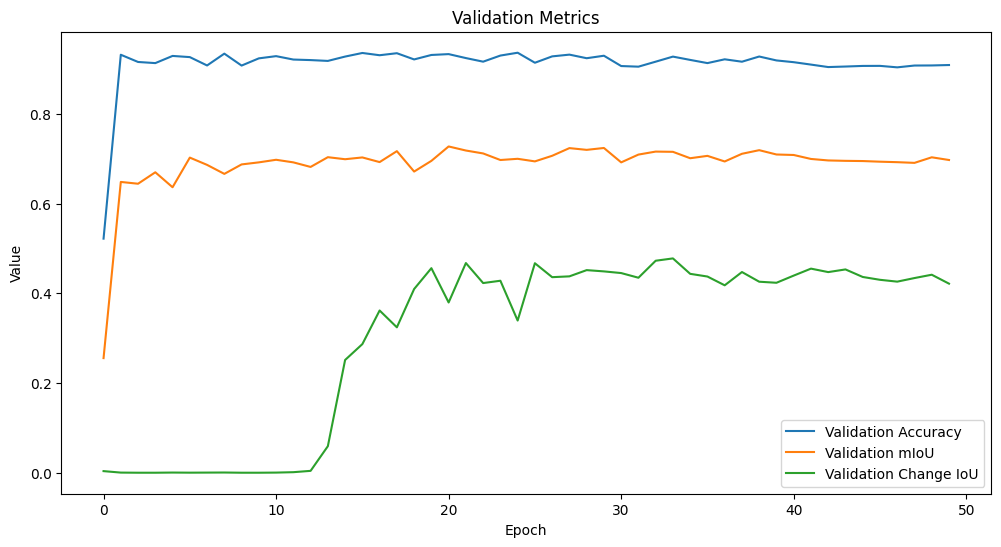

In [21]:
# Visualize the trainng curves
plt.figure(figsize=(12, 6))
plt.plot(logs["train_loss"], label="Train Loss")
plt.plot(logs["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Losses")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["learning_rate"], label="Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Learning Rate Schedule")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(logs["val_acc"], label="Validation Accuracy")
plt.plot(logs["val_miou"], label="Validation mIoU")
plt.plot(logs["val_iou_change"], label="Validation Change IoU")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("Validation Metrics")
plt.legend()
plt.show()

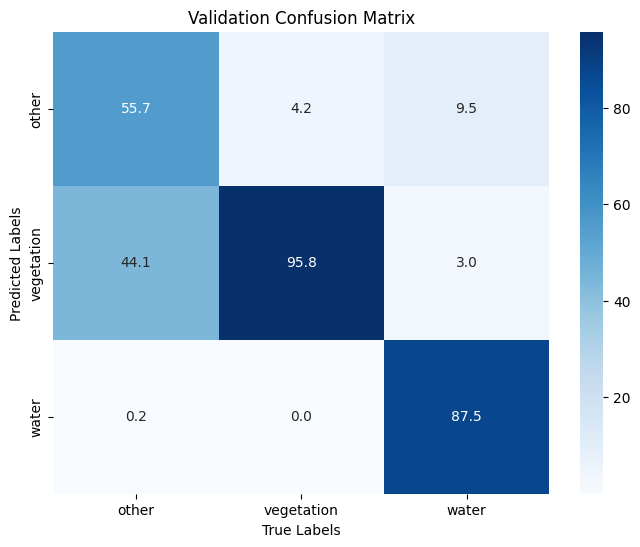

Validation Accuracy: 92.78%, mIoU: 71.55%


In [22]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix.float() / best_model_val_conf_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

val_acc = best_model_val_conf_matrix.trace().float() / best_model_val_conf_matrix.sum().float()
val_miou = (torch.diagonal(best_model_val_conf_matrix).float() / (best_model_val_conf_matrix.sum(dim=1).float() + best_model_val_conf_matrix.sum(dim=0).float() - torch.diagonal(best_model_val_conf_matrix).float())).mean()
print(f"Validation Accuracy: {val_acc*100:.2f}%, mIoU: {val_miou*100:.2f}%")

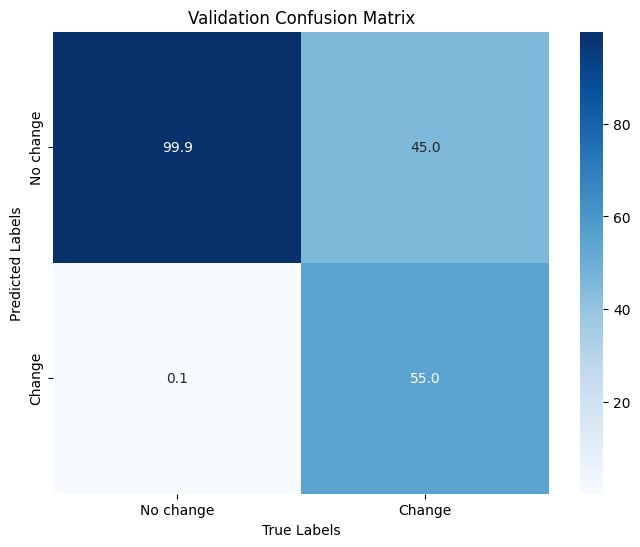

Validation Change IoU: 47.79%, FPR: 0.12%


In [23]:
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
val_conf_matrix_normalized = best_model_val_conf_matrix_change.float() / best_model_val_conf_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(val_conf_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=["No change", "Change"], yticklabels=["No change", "Change"])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Validation Confusion Matrix')
plt.show()

val_change_iou = best_model_val_conf_matrix_change[1, 1].float() / (best_model_val_conf_matrix_change[1, :].sum().float() + best_model_val_conf_matrix_change[:, 1].sum().float() - best_model_val_conf_matrix_change[1, 1].float())
val_false_positive_rate = best_model_val_conf_matrix_change[1, 0].float() / (best_model_val_conf_matrix_change[1, 0].float() + best_model_val_conf_matrix_change[0, 0].float())
print(f"Validation Change IoU: {val_change_iou*100:.2f}%, FPR: {val_false_positive_rate*100:.2f}%")

### 3.4 Evaluation on test set

In [24]:
canva_lab = torch.zeros(24, 256, 512).long()
canva_pred = torch.zeros(24, 256, 512).long()
canva_lab_change = torch.zeros(23, 256, 512).long()
canva_pred_change = torch.zeros(23, 256, 512).long()
ij_list = [[i, j] for i in range(4) for j in range(8)]
best_model_change.eval()
times = []
for k in range(len(test_set)):
    imgs, labs = test_set[k]
    imgs = imgs.to(device)
    with torch.no_grad():
        start = time.time()
        sem_logits, change_logits = best_model_change(imgs[None], DAYS[None])
        end = time.time()
        times.append(end-start)
    pred_sem =  torch.argmax(sem_logits[0], dim=1).detach().cpu()
    pred_change = torch.argmax(change_logits[0], dim=1).detach().cpu()
    labs = labs.detach().cpu()
    labs_change = (labs[:-1] != labs[1:]).long()
    i, j = ij_list[k]
    canva_lab[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs
    canva_pred[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_sem
    canva_lab_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = labs_change
    canva_pred_change[:, i*64:(i+1)*64, j*64:(j+1)*64] = pred_change

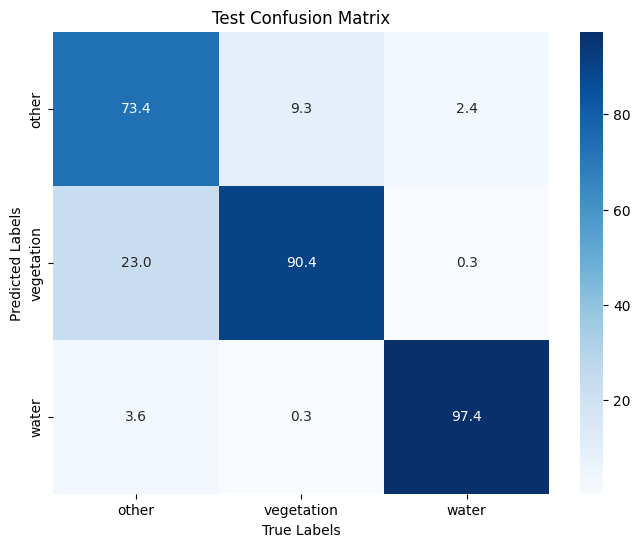

In [25]:
test_confusion_matrix = torch.bincount(canva_pred.flatten().long() * 3 + canva_lab.flatten().long(), minlength=9).reshape(3, 3)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_normalized = test_confusion_matrix.float() / test_confusion_matrix.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)], yticklabels=[DYNAMICEARTHNET_CLASSES[i]["label"] for i in range(3)])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix')
plt.show()

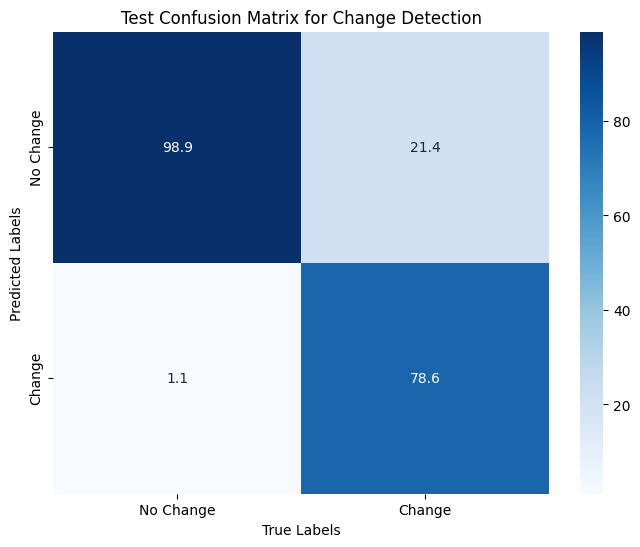

In [26]:
test_confusion_matrix_change = torch.bincount(canva_pred_change.flatten().long() * 2 + canva_lab_change.flatten().long(), minlength=4).reshape(2, 2)
# plot val_confusion matrix
plt.figure(figsize=(8, 6))
# normalize the confusion matrix for better visualization
test_confusion_matrix_change_normalized = test_confusion_matrix_change.float() / test_confusion_matrix_change.sum(dim=0, keepdim=True) * 100
sns.heatmap(test_confusion_matrix_change_normalized.cpu().numpy(), annot=True, fmt='.1f', cmap='Blues', xticklabels=['No Change', 'Change'], yticklabels=['No Change', 'Change'])
plt.ylabel('Predicted Labels')
plt.xlabel('True Labels')
plt.title('Test Confusion Matrix for Change Detection')
plt.show()

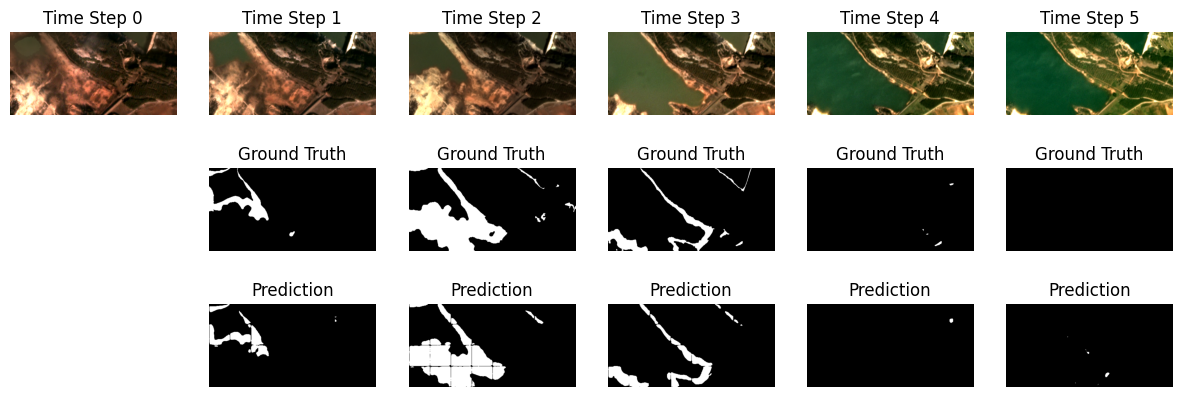

In [27]:
plt.figure(figsize=(15, 5))
for time_step in range(6):
    plt.subplot(3, 6, time_step + 1)
    plt.title(f"Time Step {time_step}")
    plot_image(images[time_step, :, 512:768:, :512])
    if time_step > 0:
        plt.subplot(3, 6, time_step + 7)
        plt.title(f"Ground Truth")
        plt.imshow(canva_lab_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
        plt.subplot(3, 6, time_step + 13)
        plt.title(f"Prediction")
        plt.imshow(canva_pred_change[time_step].numpy(), cmap='gray')
        plt.axis('off')
plt.show()

In [28]:
acc = test_confusion_matrix.diag().sum().item() / test_confusion_matrix.sum().item()
per_class_iou = test_confusion_matrix.diag() / (test_confusion_matrix.sum(dim=1) + test_confusion_matrix.sum(dim=0) - test_confusion_matrix.diag())
miou = per_class_iou.mean().item()
change_iou = test_confusion_matrix_change[1, 1].float() / (test_confusion_matrix_change[1, 1].float() + test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 1].float())
sc = compute_SC(canva_pred, canva_lab)
false_positive_rate = test_confusion_matrix_change[1, 0].float() / (test_confusion_matrix_change[1, 0].float() + test_confusion_matrix_change[0, 0].float())

print(f"Test inference time: {np.mean(times)*1e3:.1f}ms ({np.std(times)*1e3:.1f}ms) per time series")
print(f"Sem Seg Acc:         {acc*100:.1f}")
print(f"Sem Seg mIoU:        {miou*100:.1f}")
print(f"Change IoU:          {change_iou.item() * 100:.1f}")
print(f"SC:                  {sc * 100:.1f}")
print(f"False Positive Rate: {false_positive_rate.item() * 100:.2f}")

Test inference time: 18.0ms (2.5ms) per time series
Sem Seg Acc:         89.0
Sem Seg mIoU:        78.6
Change IoU:          60.6
SC:                  59.0
False Positive Rate: 1.10


## 4. Test results and conclusions

Gather the test results of all models trained in tutorials 1 and 2 in the table below.

| Method        | Inference Time in ms (std) | Sem. Seg. Acc. | Sem. Seg. mIoU | Change IoU | SC | False Positive Rate |
|---------------|----------------------------|----------------|----------------|------------|----|---------------------|
| UNet          |  () |  |  |  |  |
| DualUNet      |  () |  |  |  |  |
| MultiDualUNet |  () |  |  |  |  |

Try and compare the different baselines, focusing on their inference time, change IoU, SC, and false positive rate.  
What is the best model according to these metrics? Why? Once yur done, you can report the scores [in this spreadsheet](https://docs.google.com/spreadsheets/d/1ZeGHwPC2sFupiJ-KKqNgPOo-qnsbcJAFWBlYSVpHIf8/edit?usp=sharing).

### Bibliography

[1] Toker et al. _DynamicEarthNet: Daily Multi-Spectral Satellite Dataset for Semantic Change Segmentation_. CVPR 2022.  
[2] Benidir et al. _The Change You Want To Detect: Semantic Change Detection In Earth Observation With Hybrid Data Generation_. CVPR 2025.  
[3] Garnot et al. _Panoptic Segmentation of Satellite Image Time Series with Convolutional Temporal Attention Networks_. ICCV 2021.